# Case Studies: Multi-Channel Bubble Anatomy

This notebook looks at individual episodes through all three information
channels at once:

1. **Equity volatility** (CRSP): sector vol vs market vol, plus intra-sector
   correlation.
2. **Credit-implied volatility** (TRACE bond spreads, Merton-inverted): what
   the bond market thinks asset risk is, and the CIV-equity wedge.
3. **SEC filing language** (10-K/10-Q): negativity and risk-escalation
   metrics.

Everything is aligned on **tau = months relative to the run-up peak**
(red dashed line), using the sector-level derived data in
`data/multichannel/` (included in the repo; no credentials needed).

The point of these panels is qualitative: the three channels do not move
together, and the divergences are where the model's signal lives.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
DATA_DIR = ROOT / "data" / "multichannel"

plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "figure.dpi": 110,
})

## Load the three channels

Sector-month panels per episode: vol metrics, SEC text metrics, and CIV
metrics, each keyed by episode id.

In [2]:
def load_all():
    vol, sec, civ = {}, {}, {}
    for f in (DATA_DIR / "metrics").glob("*.parquet"):
        vol[f.stem] = pd.read_parquet(f)
    sec_all = pd.read_parquet(DATA_DIR / "sec_metrics" / "_all_sec_metrics.parquet")
    for bid in sec_all.bubble_id.unique():
        sec[bid] = sec_all[sec_all.bubble_id == bid].copy()
    civ_all = pd.read_parquet(DATA_DIR / "civ_metrics" / "_all_civ_metrics.parquet")
    for bid in civ_all.bubble_id.unique():
        civ[bid] = civ_all[civ_all.bubble_id == bid].copy()
    return vol, sec, civ


def align_on_peak(df, peak_date):
    peak_ts = pd.Timestamp(peak_date + "-01")
    df = df.copy()
    df["tau"] = ((df["date"].dt.year - peak_ts.year) * 12
                 + df["date"].dt.month - peak_ts.month)
    return df


vol, sec, civ = load_all()
print(f"Vol: {len(vol)} episodes, SEC: {len(sec)}, CIV: {len(civ)}")

Vol: 78 episodes, SEC: 36, CIV: 42


## Four leverage-bubble case studies

Banks (GFC), homebuilders, shale oil, and the commodity supercycle: the four
canonical *leverage* bubbles, where the model works best.

Each column is one episode; rows are the three channels.

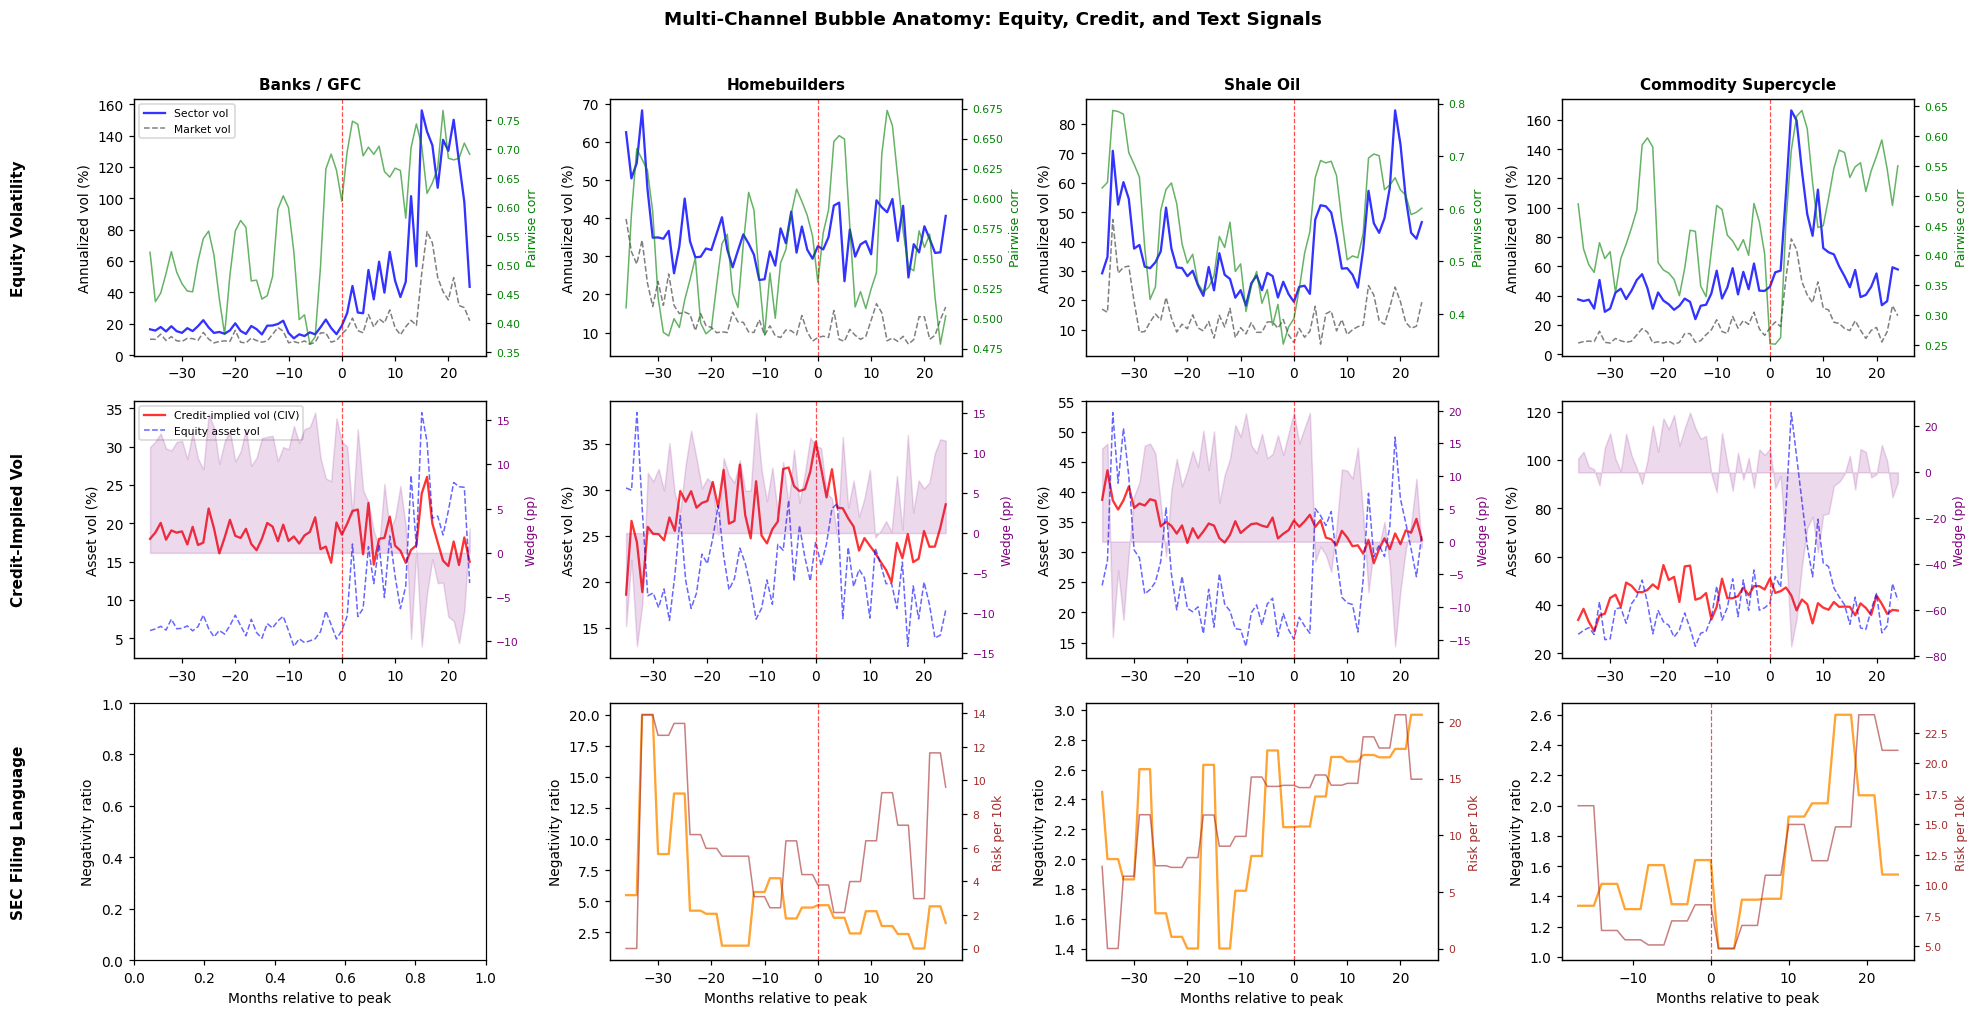

In [3]:
CASE_STUDIES = [
    ("banks_gfc", "Banks / GFC", "2007-06"),
    ("homebuilders", "Homebuilders", "2005-07"),
    ("shale", "Shale Oil", "2014-06"),
    ("commodity_super", "Commodity Supercycle", "2008-06"),
]

cases = [c for c in CASE_STUDIES if c[0] in vol and c[0] in civ]
n_cases = len(cases)

fig, axes = plt.subplots(3, n_cases, figsize=(4.5 * n_cases, 9), squeeze=False)

for col_i, (bid, label, peak) in enumerate(cases):
    v = align_on_peak(vol[bid], peak)
    c = align_on_peak(civ[bid], peak)
    v = v[(v["tau"] >= -36) & (v["tau"] <= 24)]
    c = c[(c["tau"] >= -36) & (c["tau"] <= 24)]

    # Row 1: equity vol + correlation
    ax1 = axes[0, col_i]
    if "sector_vol" in v.columns:
        ax1.plot(v["tau"], v["sector_vol"] * 100, "b-", lw=1.5,
                 label="Sector vol", alpha=0.8)
    if "market_vol" in v.columns:
        ax1.plot(v["tau"], v["market_vol"] * 100, "k--", lw=1, alpha=0.5,
                 label="Market vol")
    ax1.axvline(0, color="red", lw=0.8, ls="--", alpha=0.7)
    ax1.set_ylabel("Annualized vol (%)")
    ax1.set_title(label, fontweight="bold")
    if "metric_c" in v.columns:
        ax1b = ax1.twinx()
        ax1b.plot(v["tau"], v["metric_c"], "g-", lw=1, alpha=0.6)
        ax1b.set_ylabel("Pairwise corr", color="g", fontsize=8)
        ax1b.tick_params(axis="y", labelcolor="g", labelsize=7)
    if col_i == 0:
        ax1.legend(loc="upper left", fontsize=7)

    # Row 2: CIV and wedge
    ax2 = axes[1, col_i]
    ax2.plot(c["tau"], c["metric_o"] * 100, "r-", lw=1.5,
             label="Credit-implied vol (CIV)", alpha=0.8)
    if "equity_asset_vol" in c.columns:
        ev = c.dropna(subset=["equity_asset_vol"])
        ax2.plot(ev["tau"], ev["equity_asset_vol"] * 100, "b--", lw=1,
                 alpha=0.6, label="Equity asset vol")
    ax2.axvline(0, color="red", lw=0.8, ls="--", alpha=0.7)
    ax2.set_ylabel("Asset vol (%)")
    if "metric_p" in c.columns:
        cp = c.dropna(subset=["metric_p"])
        if not cp.empty:
            ax2b = ax2.twinx()
            ax2b.fill_between(cp["tau"], cp["metric_p"] * 100, 0,
                              alpha=0.15, color="purple")
            ax2b.set_ylabel("Wedge (pp)", color="purple", fontsize=8)
            ax2b.tick_params(axis="y", labelcolor="purple", labelsize=7)
    if col_i == 0:
        ax2.legend(loc="upper left", fontsize=7)

    # Row 3: SEC metrics
    ax3 = axes[2, col_i]
    if bid in sec:
        s = align_on_peak(sec[bid], peak)
        s = s[(s["tau"] >= -36) & (s["tau"] <= 24)]
        if "metric_n" in s.columns:
            sn = s.dropna(subset=["metric_n"])
            ax3.plot(sn["tau"], sn["metric_n"], "darkorange", lw=1.5,
                     label="Negativity ratio", alpha=0.8)
        if "metric_k" in s.columns:
            sk = s.dropna(subset=["metric_k"])
            if not sk.empty:
                ax3b = ax3.twinx()
                ax3b.plot(sk["tau"], sk["metric_k"], "brown", lw=1, alpha=0.6)
                ax3b.set_ylabel("Risk per 10k", color="brown", fontsize=8)
                ax3b.tick_params(axis="y", labelcolor="brown", labelsize=7)
    ax3.axvline(0, color="red", lw=0.8, ls="--", alpha=0.7)
    ax3.set_xlabel("Months relative to peak")
    ax3.set_ylabel("Negativity ratio")
    if col_i == 0 and bid in sec:
        ax3.legend(loc="upper left", fontsize=7)

for row_i, label in enumerate(["Equity Volatility", "Credit-Implied Vol",
                                "SEC Filing Language"]):
    axes[row_i, 0].annotate(label, xy=(-0.35, 0.5), xycoords="axes fraction",
                            fontsize=10, fontweight="bold", rotation=90,
                            va="center")

fig.suptitle("Multi-Channel Bubble Anatomy: Equity, Credit, and Text Signals",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Reading the panels.**

- **Banks/GFC**: the textbook case. Equity vol is calm into the peak while
  CIV creeps up: the bond market saw asset risk that equity prices ignored.
  Filing negativity rises *before* the peak.
- **Homebuilders**: leverage builds through the run-up; the CIV-equity wedge
  (purple) widens well before the equity market turns.
- **Shale**: a slow-motion version; text metrics deteriorate gradually
  through 2013-14.
- **Commodity supercycle**: the control case among the four: channels are
  more synchronized, and the crash arrives with the 2008 macro shock rather
  than being telegraphed by any one channel.

The general pattern: *no single channel is reliable, but disagreement between
them is informative*, which is exactly why the multi-channel model beats
vol-only in Section 2 of the main-results notebook.

## Lead-lag: which channel moves first?

Cross-correlations between channels at lags of -12 to +12 months, pooled
across all episodes with all three channels. Positive lag means the Y
variable leads.

10 episodes with all three channels, 1,072 pooled sector-months


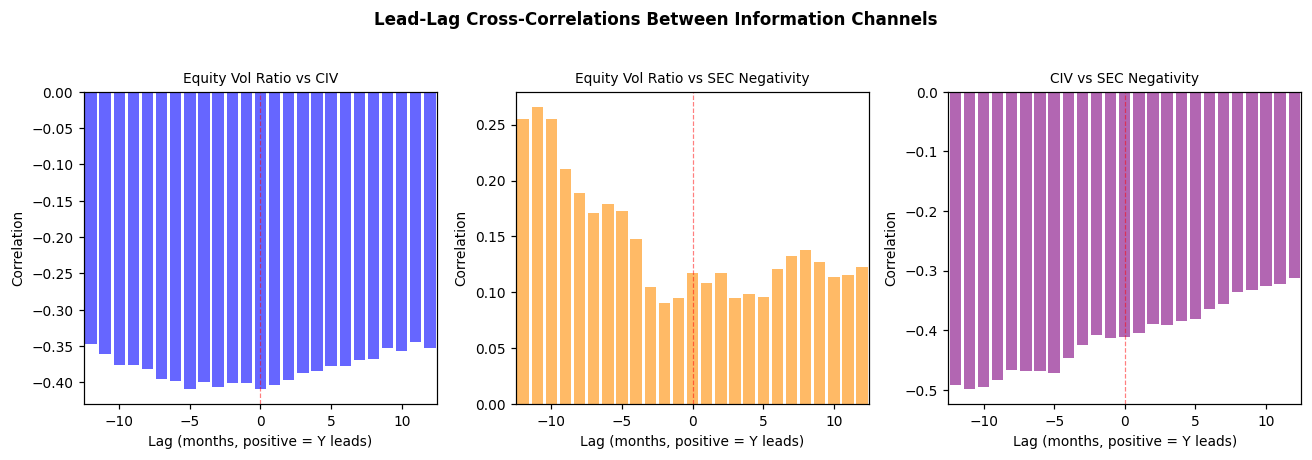

In [4]:
from src.catalog import get_bubbles

pairs = []
for bubble in get_bubbles():
    bid = bubble["id"]
    if bid not in vol or bid not in civ or bid not in sec:
        continue
    peak = bubble["peak_date"]
    if peak is None:
        continue
    v = align_on_peak(vol[bid], peak)
    c = align_on_peak(civ[bid], peak)
    s = align_on_peak(sec[bid], peak)
    merged = v[["tau", "metric_a", "sector_vol"]].merge(
        c[["tau", "metric_o"]], on="tau", how="inner")
    merged = merged.merge(s[["tau", "metric_n", "metric_k"]],
                          on="tau", how="inner")
    if len(merged) >= 12:
        pairs.append(merged)

all_pairs = pd.concat(pairs, ignore_index=True)
print(f"{len(pairs)} episodes with all three channels, "
      f"{len(all_pairs):,} pooled sector-months")

max_lag = 12
lags = range(-max_lag, max_lag + 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
channel_pairs = [
    ("metric_a", "metric_o", "Equity Vol Ratio vs CIV", "b"),
    ("metric_a", "metric_n", "Equity Vol Ratio vs SEC Negativity", "darkorange"),
    ("metric_o", "metric_n", "CIV vs SEC Negativity", "purple"),
]
for ax, (col_x, col_y, title, color) in zip(axes, channel_pairs):
    corrs = []
    for lag in lags:
        shifted = all_pairs.copy()
        shifted[col_y] = shifted[col_y].shift(lag)
        valid = shifted.dropna(subset=[col_x, col_y])
        corrs.append(valid[col_x].corr(valid[col_y])
                     if len(valid) >= 10 else np.nan)
    ax.bar(list(lags), corrs, color=color, alpha=0.6, width=0.8)
    ax.axhline(0, color="k", lw=0.5)
    ax.axvline(0, color="red", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlabel("Lag (months, positive = Y leads)")
    ax.set_ylabel("Correlation")
    ax.set_title(title, fontsize=9)
    ax.set_xlim(-max_lag - 0.5, max_lag + 0.5)

fig.suptitle("Lead-Lag Cross-Correlations Between Information Channels",
             fontsize=11, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

**Reading the figure.** The cross-correlations are modest and broadly
symmetric: no channel systematically leads another by a clean, exploitable
margin. This is consistent with the project's timing null: the channels carry
*complementary cross-sectional* information (which sectors are fragile), not
*sequential* information (when the crash comes).

For the quantitative version of that statement, permutation tests, and the
walk-forward caveat, see `notebooks/01_main_results.ipynb`.